Every plot in [Data Visualization I](https://lizhen0909.github.io/stat303-1-sec20-coursebook/data_viz_1.html) was a single picture drawn with a single command. We wrote
`plt.hist(...)` or `sns.boxplot(...)`, added labels, and a figure appeared. We never had
to ask *where* it appeared, because there was only one place it could go.

That question — where does this plot go? — is what this chapter is about. Once you want
two plots side by side, or a grid of six, you need to name the thing you are drawing into.
Doing that requires learning:

1. The **anatomy** of a matplotlib figure, so the vocabulary makes sense.
2. The **two interfaces** matplotlib offers for drawing, and why you should prefer the
   second one from now on.
3. `plt.subplots()` — how to create a grid of panels and draw into each one.
4. How **seaborn** fits into all this, including why some seaborn functions refuse to be
   put in a panel.

Along the way we will deliver on two promises from that chapter: fitting a separate
regression line per group with `lmplot`, and explaining what "figure-level" means.

By the end of this chapter you should be able to:

- Name the parts of a matplotlib figure — figure, axes, axis, artist — and use "axes" to mean one panel.
- Draw with the explicit, object-oriented interface, and translate a pyplot command into its `ax` equivalent.
- Explain why a stray `plt.title()` lands on the wrong panel, and predict which panel it hits.
- Build a grid with `plt.subplots()`, index its panels correctly in one and two dimensions, and loop over them with `axes.flat`.
- Choose `sharex` / `sharey` when panels should be comparable, and give a figure enough room with `figsize` and `layout="constrained"`.
- Lay out an uneven figure with `plt.subplot_mosaic()` or `GridSpec`.
- Tell a seaborn axes-level function from a figure-level one, and say which accepts `ax=` and which builds panels with `col=` and `row=`.
- Magnify a crowded region with an inset panel, and mark what it magnifies.
- Place a summary inset in figure coordinates, and decide whether an inset keeps its ticks.
- Format tick labels through `ax.xaxis` and `ax.yaxis` — thousands separators, percentages, and rotated category names.
- Give a multi-panel figure one shared legend, figure-wide titles, and a saved file that is not cut off.
- Judge whether a set of plots belongs in one figure at all.

Complete the [practice activity](#practice-activity-build-and-defend-a-multi-panel-figure)
after the worked examples.

## Set Up Your Chapter Files {#set-up-your-chapter-files}

Download the [Data Visualization II practice kit](https://lizhen0909.github.io/stat303-1-sec20-coursebook/downloads/data-visualization-2-practice.zip).
Extract `stat303-data-visualization-2` inside the `stat303-setup` project from the setup
chapters and select that project's verified Python environment.

```text
stat303-setup/
├── .venv/
└── stat303-data-visualization-2/
    ├── data_viz_2_examples.ipynb
    ├── activity09.ipynb
    └── README.md
```

Run `data_viz_2_examples.ipynb` for the lesson and complete `activity09.ipynb` for your
own activity report, with `stat303-data-visualization-2` as the notebook working folder.

**This kit has no `data/` folder, and nothing belongs in one.** As in the previous
chapter, every figure uses the Palmer penguins dataset that comes with seaborn, which
`sns.load_dataset("penguins")` hands you in one line. The first call downloads the file
and caches it on your computer, so you need a network connection once; after that it
loads from the cache. If you would rather read it from a file of your own, the note
under [The data](https://lizhen0909.github.io/stat303-1-sec20-coursebook/data_viz_1.html#the-data) in the previous chapter shows the one-line
change.

The three libraries and the aliases `pd`, `plt`, and `sns` are the same as in
[Data Visualization I](https://lizhen0909.github.io/stat303-1-sec20-coursebook/data_viz_1.html).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("penguins")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


**Environment check:** This chapter uses pandas, matplotlib, and seaborn. If an import
fails, check the selected notebook kernel first. If a package is missing, activate your
project environment and run this command in its terminal:

```bash
python -m pip install pandas matplotlib seaborn
```

pandas and matplotlib went into that environment in
[Project Environments, Packages, and File Paths](https://lizhen0909.github.io/stat303-1-sec20-coursebook/python_venv.html#install-packages-in-the-intended-environment),
and seaborn is the package that chapter installs as its worked example. This chapter
leans on matplotlib more heavily than the last one, so make sure the import cell runs
before you go on.

Same Palmer penguins dataset as before: 344 penguins, four numeric measurement columns
and three categorical columns.

## Anatomy of a figure

Matplotlib's vocabulary is the single biggest obstacle to learning it, because two of the
central words look almost identical. Learn these four terms and most documentation
suddenly becomes readable.

**Figure** — the whole canvas. It is the sheet of paper. A figure has a size
(`figsize=(width, height)` in inches), and it is the thing you save to a file. A figure can
hold one panel or twenty.

**Axes** — **one panel**: a single plot with its own x-axis, y-axis, title, and data. This
is the confusing one. Despite sounding plural, *one* `Axes` object is *one* rectangular
plot. A figure with six panels contains six Axes. Whenever you read "axes" in matplotlib
documentation or in a variable name like `ax`, read it as **"panel"** and you will rarely
be confused.

**Axis** — one of the actual number lines, the x-axis or the y-axis, belonging to an Axes.
You will interact with these much less often than with Axes.

**Artist** — everything drawable: each line, bar, dot, piece of text, tick, and legend.
Everything you see on a figure is an Artist, including the Axes themselves.

The containment goes one way:

```
Figure  (the canvas, what you save)
└── Axes  (a panel — one plot; there can be many)
    ├── Axis  (the x number line)
    ├── Axis  (the y number line)
    └── Artists  (the bars, dots, lines, text, legend)
```

::: {.callout-tip}
## Axes vs. Axis

**Axes = one panel.** **Axis = one number line.** The plural of Axes is also "axes",
which is why people say "a figure with three axes" meaning three panels. If a sentence
seems to be using the word strangely, substitute "panel" and see if it makes sense.
:::

In the last chapter, every plot created one Figure containing exactly one Axes — we just
never referred to either of them by name.

## The two interfaces

Matplotlib gives you two different ways to draw the same plot. This is the main reason
matplotlib code found online looks inconsistent: you are seeing two styles mixed
together, sometimes in the same code block. Once you can tell them apart, the confusion
mostly disappears.

### Interface 1: pyplot, the implicit interface

This is what the last chapter used. You call functions on `plt` directly, and matplotlib
keeps track of a **"current figure"** and a **"current Axes"** behind the scenes. Every
`plt.` command you issue applies to whatever is current.

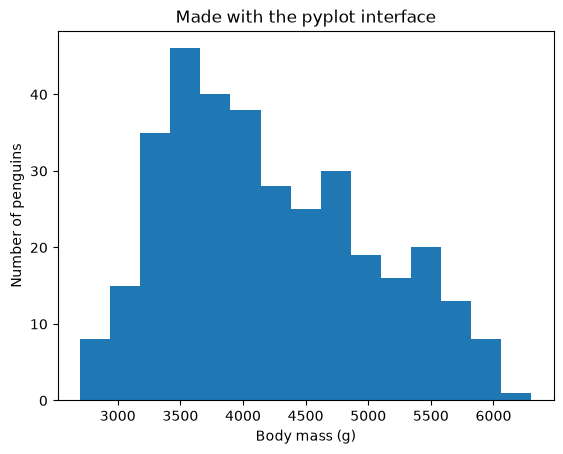

In [2]:
plt.hist(df["body_mass_g"], bins=15)
plt.xlabel("Body mass (g)")
plt.ylabel("Number of penguins")
plt.title("Made with the pyplot interface")
plt.show()

There is no variable anywhere in that code holding the figure or the panel. `plt.hist`
noticed that no figure existed, created one with a single Axes, made it current, and drew
into it. The next three commands each modified "the current Axes" — that same one.

This style is also called the **implicit** interface (the target is implied) or the
**state-machine** interface (matplotlib holds state: which panel is current). It is
modeled on MATLAB, which is where the design comes from.

It is excellent for one quick plot, and that is exactly what we used it for.

### Interface 2: the object-oriented, explicit interface

Here you ask for the figure and panel up front, keep them in variables, and call methods
**on those variables**:

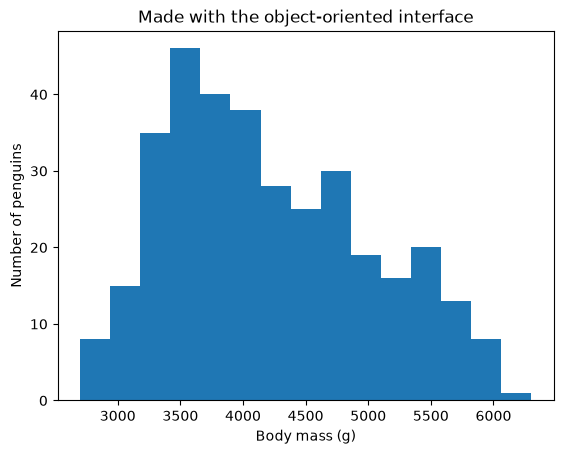

In [3]:
fig, ax = plt.subplots()

ax.hist(df["body_mass_g"], bins=15)
ax.set_xlabel("Body mass (g)")
ax.set_ylabel("Number of penguins")
ax.set_title("Made with the object-oriented interface")
plt.show()

The same picture, with one important difference: nothing is implied. `plt.subplots()`
creates a Figure and an Axes and hands both back, so `fig` is the canvas and `ax` is the
panel. Every subsequent command says explicitly which panel it is drawing into.

Read that first line carefully, because it appears in nearly every matplotlib program you
will ever write:

```python
fig, ax = plt.subplots()
```

`plt.subplots()` returns **two** things, and the two names on the left unpack them:
`fig` is the Figure, `ax` is the Axes. You can name them anything, but `fig` and `ax` are
the universal convention.

This is called the **object-oriented (OO)** or **explicit** interface.

### The translation table

The two interfaces do the same things under slightly different names. The pattern is that
most `plt.something(...)` functions become `ax.set_something(...)` methods:

| pyplot (implicit) | object-oriented (explicit) |
|---|---|
| `plt.plot(...)`, `plt.hist(...)`, `plt.scatter(...)` | `ax.plot(...)`, `ax.hist(...)`, `ax.scatter(...)` |
| `plt.xlabel("x")` | `ax.set_xlabel("x")` |
| `plt.ylabel("y")` | `ax.set_ylabel("y")` |
| `plt.title("t")` | `ax.set_title("t")` |
| `plt.xlim(0, 10)` | `ax.set_xlim(0, 10)` |
| `plt.xticks(rotation=45)` | `ax.tick_params(axis="x", rotation=45)` |
| `plt.legend()` | `ax.legend()` |
| `plt.savefig("f.png")` | `fig.savefig("f.png")` |
| *(no equivalent)* | `fig.suptitle("figure-wide title")` |

Note the two sides of the split: **plotting commands keep their names** (`plt.hist` →
`ax.hist`) while **labelling commands gain a `set_` prefix** (`plt.xlabel` →
`ax.set_xlabel`). And notice which object each belongs to: anything about *one panel* is a
method of `ax`, while anything about *the whole canvas* — saving, a figure-wide title — is
a method of `fig`.

::: {.callout-note}
## Setting several properties at once

Because the `set_` methods all belong to the Axes, there is a shortcut that sets many at
once:

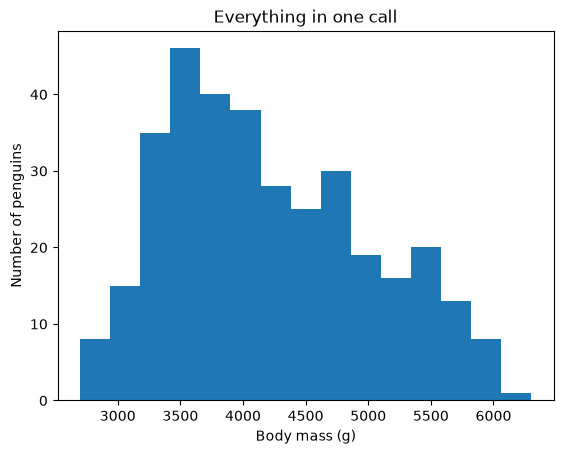

In [4]:
fig, ax = plt.subplots()
ax.hist(df["body_mass_g"], bins=15)
ax.set(xlabel="Body mass (g)", ylabel="Number of penguins",
       title="Everything in one call")
plt.show()

`ax.set(...)` accepts any property that has a `set_` method, with the prefix dropped.
It is a convenient way to keep panel styling to one line, which matters when you are
styling six panels in a loop.
:::

### Why you should prefer the explicit interface

For one plot, the pyplot style is shorter and perfectly fine. The problem begins the
moment there is more than one panel, because "the current Axes" becomes ambiguous — and
matplotlib will not warn you when you guess wrong. Consider what happens with two panels:

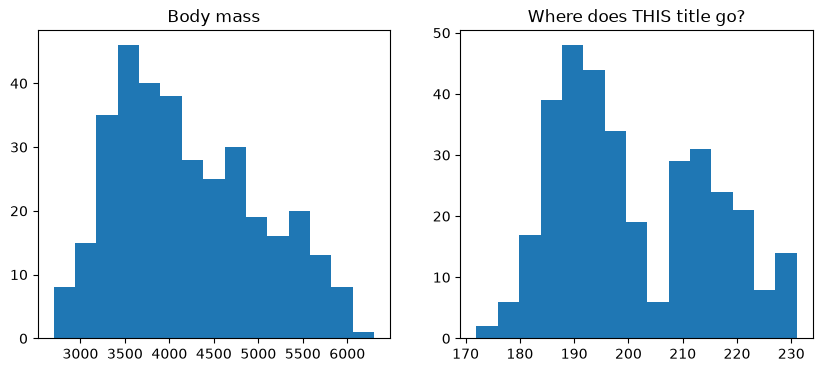

In [5]:
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(10, 4))

ax_left.hist(df["body_mass_g"], bins=15)
ax_left.set_title("Body mass")

ax_right.hist(df["flipper_length_mm"], bins=15)
ax_right.set_title("Flipper length")

plt.title("Where does THIS title go?")
plt.show()

The last `plt.title(...)` landed on the **right-hand panel**, because that was the most
recently created one and therefore "current". Worse, it did not just appear in the wrong
place — it **overwrote** that panel's existing title, so "Flipper length" is now gone. A
title meant for the whole figure silently destroyed a panel label instead. Nothing
errored; you just get a wrong plot, which is the worst kind of bug, because it looks like
output.

With the explicit interface the question cannot arise. Each command names its target:

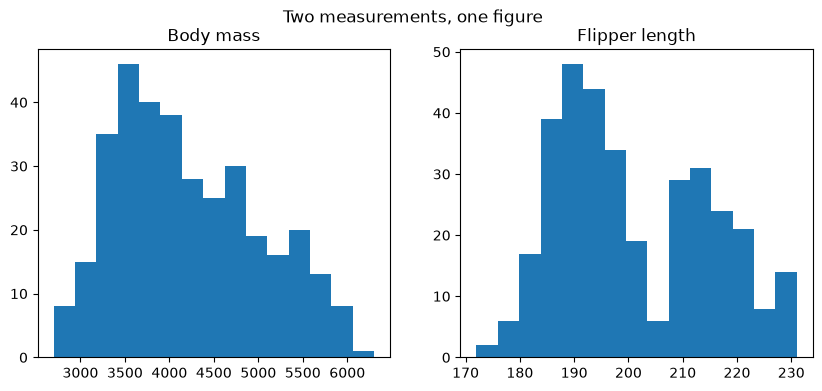

In [6]:
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(10, 4))

ax_left.hist(df["body_mass_g"], bins=15)
ax_left.set_title("Body mass")

ax_right.hist(df["flipper_length_mm"], bins=15)
ax_right.set_title("Flipper length")

fig.suptitle("Two measurements, one figure")   # figure-wide, unambiguous
plt.show()

`fig.suptitle` ("super-title") is the figure-level title, and because it is a method of
`fig` there is no doubt where it goes.

**From here on, this book uses the explicit interface.** Three reasons:

- It is unambiguous with any number of panels.
- It works the same way inside functions and loops, where there is no reliable notion of
  "current".
- It is what the matplotlib documentation itself now recommends.

The one `plt.` function we keep using is `plt.subplots()`, to create the figure in the
first place — plus `plt.show()` at the end.

## Making a grid: `plt.subplots()`

`plt.subplots(nrows, ncols)` creates a figure with a grid of panels and returns the figure
plus the panels.

<class 'numpy.ndarray'>
(2,)


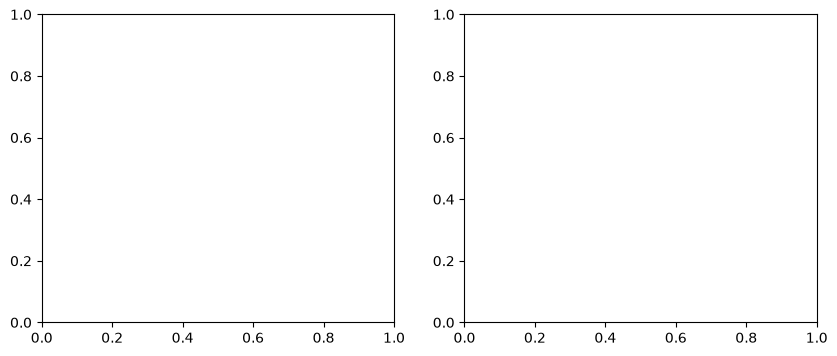

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
print(type(axes))
print(axes.shape)

With more than one panel, the second return value is a **NumPy array of Axes objects**.
You reach a panel by indexing that array. Here the grid is one row by two columns, so
`axes` has shape `(2,)` and the panels are `axes[0]` and `axes[1]`:

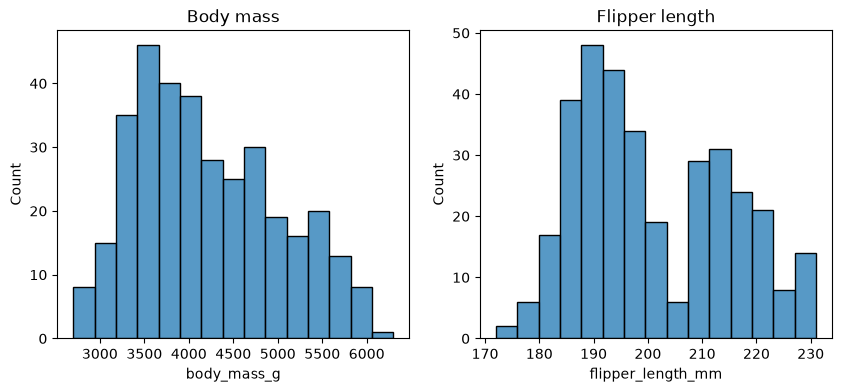

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(data=df, x="body_mass_g", bins=15, ax=axes[0])
axes[0].set_title("Body mass")

sns.histplot(data=df, x="flipper_length_mm", bins=15, ax=axes[1])
axes[1].set_title("Flipper length")

plt.show()

Note the `ax=` argument on the seaborn calls. That is how you tell a seaborn function
which panel to draw into, and we come back to it in detail below.

### Indexing: 1D versus 2D

The shape of the `axes` array follows the shape of your grid, which trips people up
constantly:

- `plt.subplots(1, 2)` → shape `(2,)` → index with **one** number: `axes[0]`
- `plt.subplots(3, 1)` → shape `(3,)` → index with **one** number: `axes[2]`
- `plt.subplots(2, 3)` → shape `(2, 3)` → index with **two**: `axes[0, 2]` (row, column)
- `plt.subplots()` → **not an array at all** — a single Axes, so `axes[0]` is an error

That last case is the classic bug: `fig, axes = plt.subplots()` followed by `axes[0]`
raises `TypeError: 'Axes' object is not subscriptable`. With one panel there is no array
to index, which is why the single-panel convention is to name it `ax`, not `axes`.

A 2×3 grid, indexed by row and column:

shape: (2, 3)


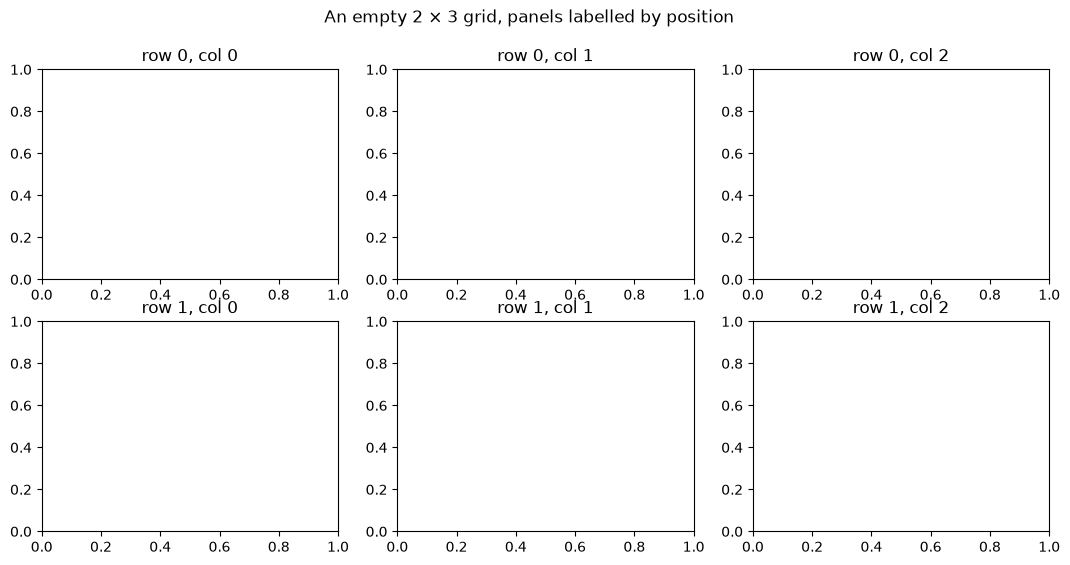

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
print("shape:", axes.shape)

axes[0, 0].set_title("row 0, col 0")
axes[0, 1].set_title("row 0, col 1")
axes[0, 2].set_title("row 0, col 2")
axes[1, 0].set_title("row 1, col 0")
axes[1, 1].set_title("row 1, col 1")
axes[1, 2].set_title("row 1, col 2")

fig.suptitle("An empty 2 × 3 grid, panels labelled by position")
plt.show()

::: {.callout-tip}
## Forcing a consistent shape

If you are writing code that should work for any grid size, the shape differences are
annoying. `squeeze=False` makes `plt.subplots` **always** return a 2D array, even for a
single panel:

In [10]:
fig, axes = plt.subplots(1, 1, squeeze=False)
print(axes.shape)       # (1, 1) — always 2D, so axes[0, 0] always works
plt.close(fig)

(1, 1)


`plt.close(fig)` discards a figure without displaying it, which is handy when you create
one only to inspect it.
:::

### Useful arguments to `plt.subplots()`

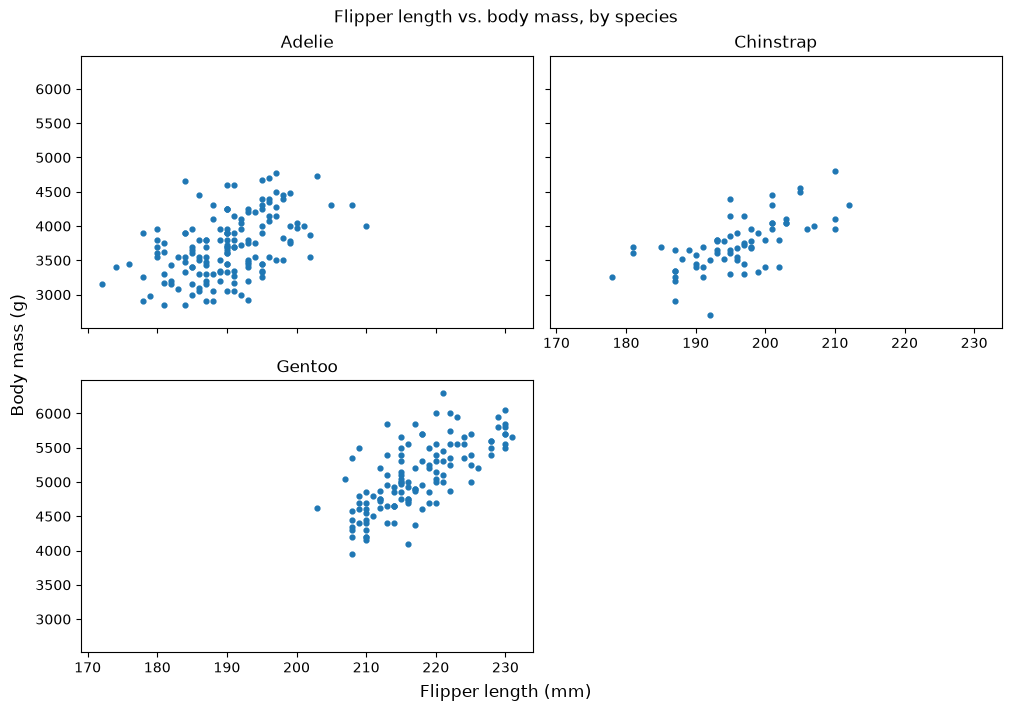

In [11]:
fig, axes = plt.subplots(2, 2,
                         figsize=(10, 7),
                         sharex=True,
                         sharey=True,
                         layout="constrained")

species_list = ["Adelie", "Chinstrap", "Gentoo"]

for ax, name in zip(axes.flat, species_list):
    subset = df[df["species"] == name]
    ax.scatter(subset["flipper_length_mm"], subset["body_mass_g"], s=12)
    ax.set_title(name)

axes.flat[3].set_visible(False)         # hide the unused fourth panel
axes[0, 1].tick_params(labelbottom=True)  # ...and give its neighbour back its x labels

fig.supxlabel("Flipper length (mm)")
fig.supylabel("Body mass (g)")
fig.suptitle("Flipper length vs. body mass, by species")
plt.show()

That example uses most of what you need day to day:

| Argument | Effect |
|---|---|
| `figsize=(w, h)` | Size of the whole figure in inches. Grids need more room than one plot |
| `sharex=True` | All panels use the same x-axis range, and inner tick labels are hidden |
| `sharey=True` | Same for the y-axis |
| `layout="constrained"` | Automatically space panels so labels and titles don't collide |
| `squeeze=False` | Always return a 2D array of Axes |

**`sharex` / `sharey` are not cosmetic.** When you compare panels side by side, the reader
assumes the axes match. If each panel auto-scales to its own data, the same visual
distance means a different quantity in each panel, and the comparison is silently
invalid — the most common way a multi-panel figure misleads. Share the axes whenever the
panels show the same variable.

**`layout="constrained"` fixes overlapping labels.** In a grid, one panel's x-axis label
tends to run into the panel below it. Constrained layout computes the spacing for you.
You will also see `fig.tight_layout()` used for this, which is the older approach and
works nearly as well; `constrained` handles shared legends better.

Two other things in that code are worth naming:

- **`axes.flat`** flattens the grid into a single sequence, so you can loop over panels
  without nested indexing. Combined with `zip`, it pairs each panel with each thing you
  want to draw — the standard way to build a grid programmatically.
- **`set_visible(False)`** hides a panel. A 2×2 grid has four slots but we only had three
  species, and an empty fourth panel with lonely tick marks looks like a mistake.

::: {.callout-important}
## Hiding a panel can strip its neighbour's tick labels

That `tick_params(labelbottom=True)` line is not decoration, and the figure is wrong
without it. With `sharex=True`, matplotlib shows x tick labels only on the **bottom** panel
of each column, since the panels above it share the same scale. Hiding the bottom-right
panel therefore removes the only x tick labels in the right-hand column, leaving the
Chinstrap panel with a bare axis and no numbers on it.

`tick_params(labelbottom=True)` turns the labels back on for that panel. Whenever you hide
a panel in a grid with shared axes, look at the panel above it and check it still has its
tick labels.
:::

### Small multiples: one loop, many panels

The real payoff of a grid is drawing the *same* plot for several variables or groups, so
they can be compared at a glance. This pattern — a grid of identically-built panels — is
called **small multiples**, and it is one of the most effective layouts in all of data
visualization.

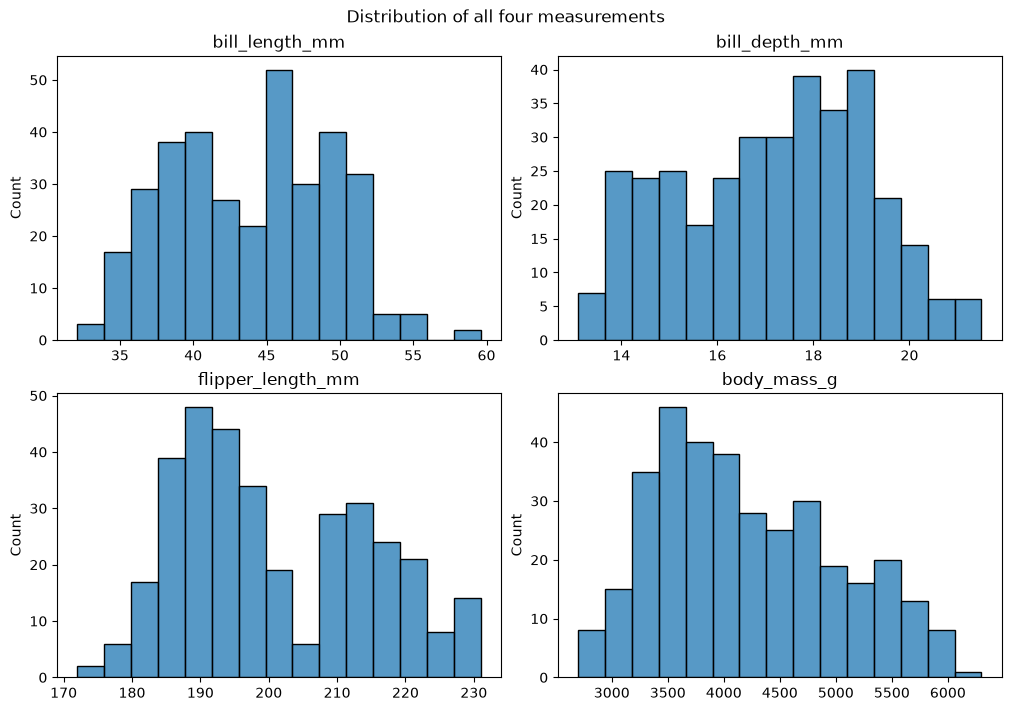

In [12]:
numeric_cols = ["bill_length_mm", "bill_depth_mm",
                "flipper_length_mm", "body_mass_g"]

fig, axes = plt.subplots(2, 2, figsize=(10, 7), layout="constrained")

for ax, column in zip(axes.flat, numeric_cols):
    sns.histplot(data=df, x=column, bins=15, ax=ax)
    ax.set_title(column)
    ax.set_xlabel("")

fig.suptitle("Distribution of all four measurements")
plt.show()

Four histograms, one loop, and adding a fifth variable would mean changing only the list
and the grid size. Note `ax.set_xlabel("")` — the column name is already in the panel
title, so clearing the axis label removes the duplication.

Here the panels show *different* variables on different scales, so `sharex` would be
wrong: forcing bill depth (14–22 mm) and body mass (2700–6300 g) onto one x-axis range
would make three of the four panels unreadable.

## Uneven layouts

A regular grid is not always the right shape. Two tools handle panels of different sizes.

### `plt.subplot_mosaic`

You draw a picture of the layout with strings, using a letter per panel, and get back a
dictionary keyed by those letters. Repeat a letter to make that panel span the space:

dict_keys(['A', 'B', 'C'])


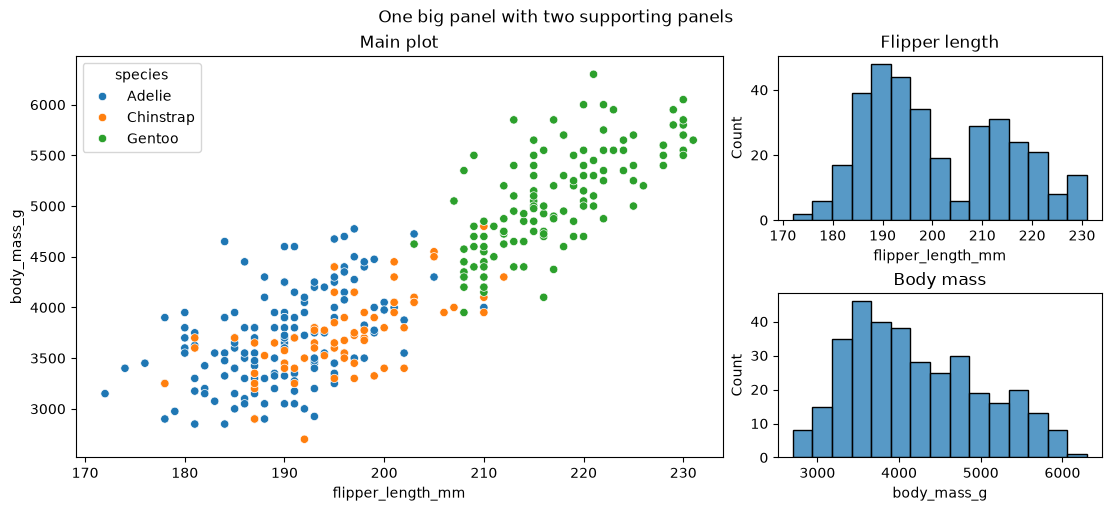

In [13]:
fig, axes = plt.subplot_mosaic(
    """
    AAB
    AAC
    """,
    figsize=(11, 5),
    layout="constrained",
)

print(axes.keys())

sns.scatterplot(data=df, x="flipper_length_mm", y="body_mass_g",
                hue="species", ax=axes["A"])
axes["A"].set_title("Main plot")

sns.histplot(data=df, x="flipper_length_mm", bins=15, ax=axes["B"])
axes["B"].set_title("Flipper length")

sns.histplot(data=df, x="body_mass_g", bins=15, ax=axes["C"])
axes["C"].set_title("Body mass")

fig.suptitle("One big panel with two supporting panels")
plt.show()

`"AAB" / "AAC"` describes a 2-row, 3-column grid in which `A` occupies the whole left
2×2 block while `B` and `C` take the right column. Because the panels come back in a
dictionary, you refer to them by meaningful letters rather than remembering that the big
one is `axes[0, 0]`. Use `.` in the string to leave a slot deliberately empty.

This is the most readable way to build an uneven layout, and it is the one to reach for
first.

### `GridSpec`

The older, more explicit approach is to create a grid and then claim rectangles from it
with slicing:

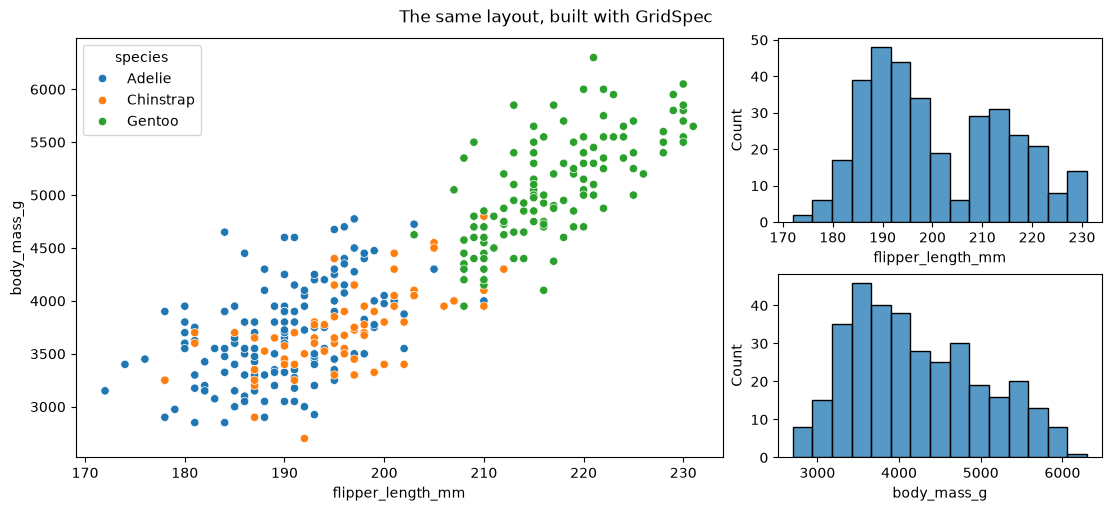

In [14]:
fig = plt.figure(figsize=(11, 5), layout="constrained")
gs = fig.add_gridspec(2, 3)

ax_main = fig.add_subplot(gs[:, 0:2])    # all rows, first two columns
ax_top = fig.add_subplot(gs[0, 2])       # row 0, last column
ax_bottom = fig.add_subplot(gs[1, 2])    # row 1, last column

sns.scatterplot(data=df, x="flipper_length_mm", y="body_mass_g",
                hue="species", ax=ax_main)
sns.histplot(data=df, x="flipper_length_mm", bins=15, ax=ax_top)
sns.histplot(data=df, x="body_mass_g", bins=15, ax=ax_bottom)

fig.suptitle("The same layout, built with GridSpec")
plt.show()

The slices work like the indexing you know: `gs[:, 0:2]` means "every row, columns 0 and
1". Note also `plt.figure()` and `fig.add_subplot()` — a figure created empty, with
panels added to it one at a time, which is what `plt.subplots()` does for you in the
regular-grid case.

`subplot_mosaic` and `GridSpec` produce identical figures here. Prefer the mosaic for
readability; you need `GridSpec` when you want finer control, such as making one row
taller than another with `height_ratios`.

## Seaborn: axes-level and figure-level functions

Now we can explain something that was postponed in the last chapter. Seaborn's plotting
functions come in two kinds, and the difference is exactly the Figure/Axes distinction we
just learned.

### Axes-level functions draw into a panel you give them

Every seaborn function used in the last chapter — `histplot`, `scatterplot`, `boxplot`,
`violinplot`, `barplot`, `countplot`, `kdeplot`, `heatmap`, `regplot`, `stripplot` — is
**axes-level**. Each draws onto a single Axes, and each accepts an `ax=` argument naming
which one. With no `ax=`, it draws into the current Axes, which is why they worked
unprompted in the last chapter.

This makes them composable with everything in this chapter:

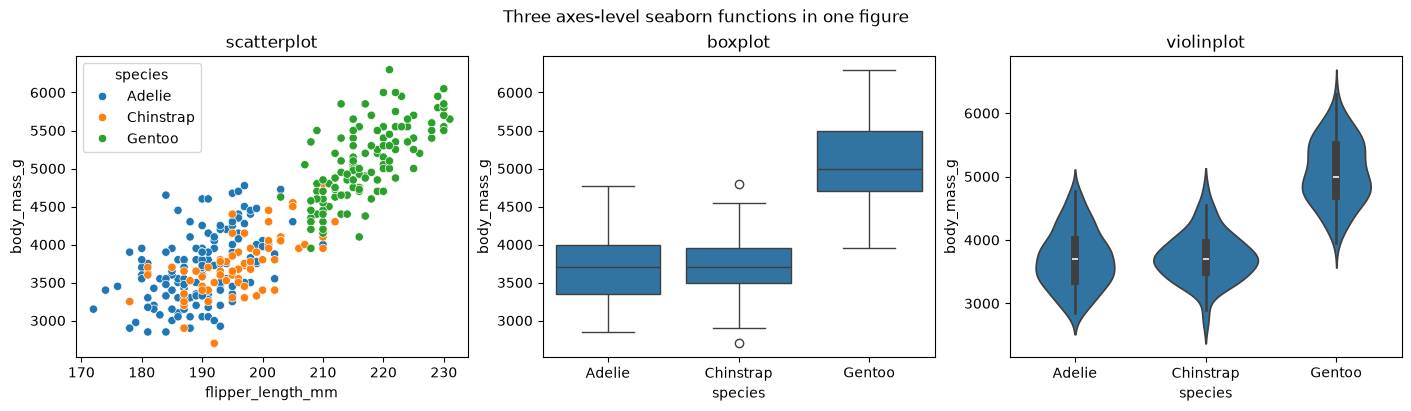

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), layout="constrained")

sns.scatterplot(data=df, x="flipper_length_mm", y="body_mass_g",
                hue="species", ax=axes[0])
axes[0].set_title("scatterplot")

sns.boxplot(data=df, x="species", y="body_mass_g", ax=axes[1])
axes[1].set_title("boxplot")

sns.violinplot(data=df, x="species", y="body_mass_g", ax=axes[2])
axes[2].set_title("violinplot")

fig.suptitle("Three axes-level seaborn functions in one figure")
plt.show()

### Figure-level functions create and own the whole figure

Seaborn also offers a smaller set of **figure-level** functions. Each one wraps a family
of axes-level functions and, crucially, **creates its own Figure**:

| Figure-level function | Wraps | Pick the inner plot with |
|---|---|---|
| `sns.displot` | `histplot`, `kdeplot`, `ecdfplot` | `kind="hist"`, `"kde"`, `"ecdf"` |
| `sns.relplot` | `scatterplot`, `lineplot` | `kind="scatter"`, `"line"` |
| `sns.catplot` | `boxplot`, `violinplot`, `barplot`, `countplot`, `stripplot`, … | `kind="box"`, `"violin"`, … |
| `sns.lmplot` | `regplot` | *(regression only)* |

In exchange for owning the figure, they give you something the axes-level functions
cannot do on their own: **automatic faceting**. Pass `col=` or `row=` and seaborn splits
the data by that column and builds one panel per group, laying out the grid itself.

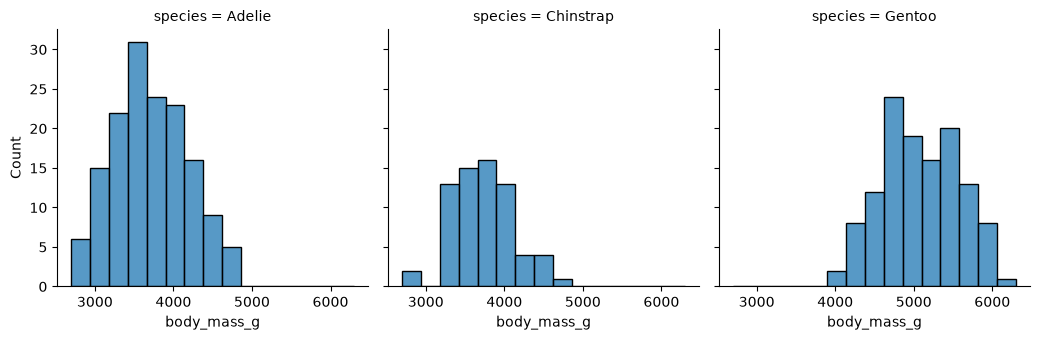

In [16]:
sns.displot(data=df, x="body_mass_g", col="species", bins=15, height=3.5)
plt.show()

One argument, `col="species"`, produced a three-panel figure with shared axes, matching
titles, and consistent spacing. Compare that with the manual loop we wrote earlier — this
is why figure-level functions exist.

Faceting composes with the visual channels from the last chapter:

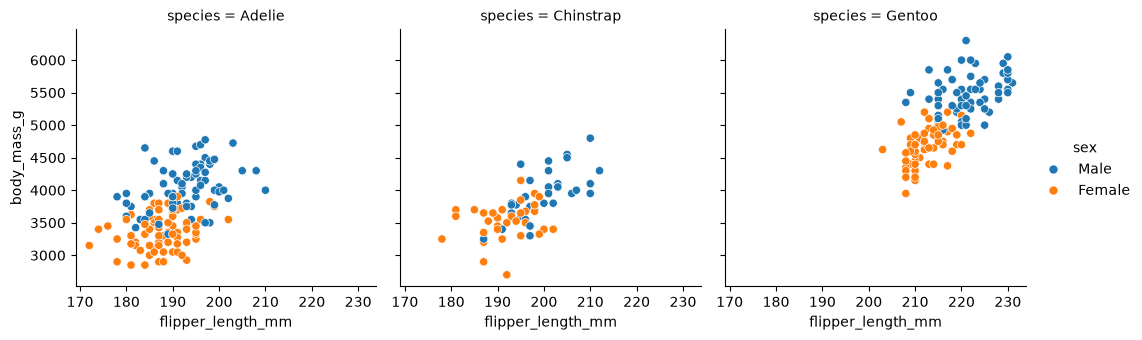

In [17]:
sns.relplot(data=df, x="flipper_length_mm", y="body_mass_g",
            col="species", hue="sex", height=3.5)
plt.show()

Now each panel is one species and color distinguishes sex — four variables, cleanly
readable, from a single call. And `catplot` faceting the categorical plots:

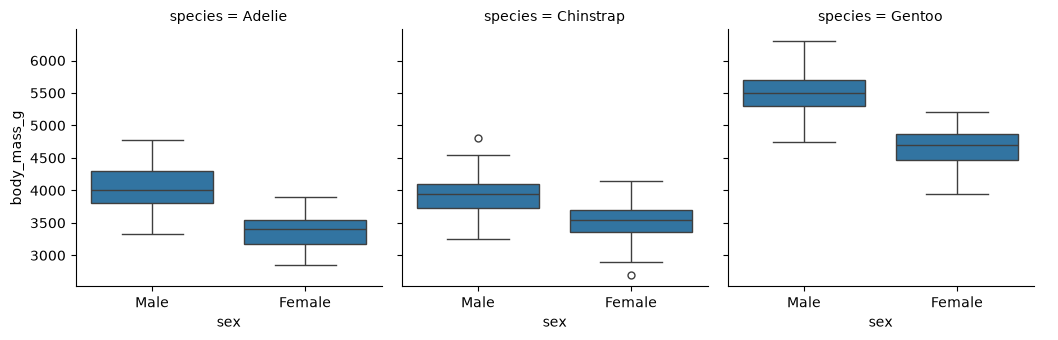

In [18]:
sns.catplot(data=df, x="sex", y="body_mass_g", col="species",
            kind="box", height=3.5)
plt.show()

Finally, the promise from the last chapter. We wanted a separate regression line per
species and had to loop `regplot` because it has no `hue`. `lmplot` is the figure-level
version, and it does have one:

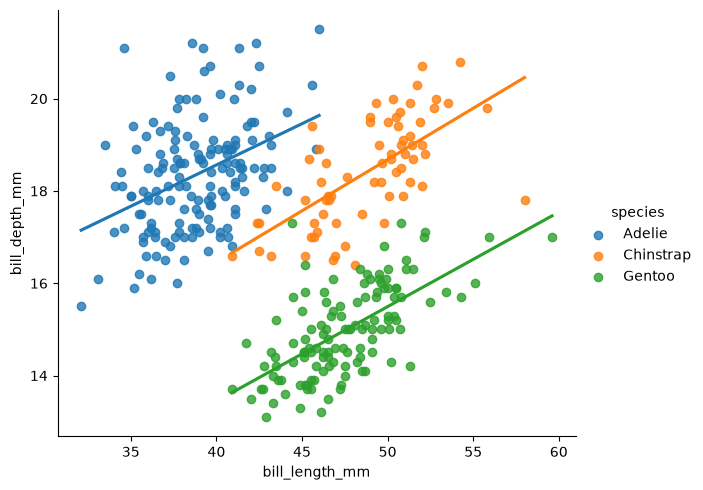

In [19]:
sns.lmplot(data=df, x="bill_length_mm", y="bill_depth_mm", hue="species",
           height=5, aspect=1.2, ci=None)
plt.show()

Three groups, three fitted lines, one call — the Simpson's paradox figure from the last
chapter without the loop. Swap `hue` for `col` and you get the same three regressions in
three separate panels:

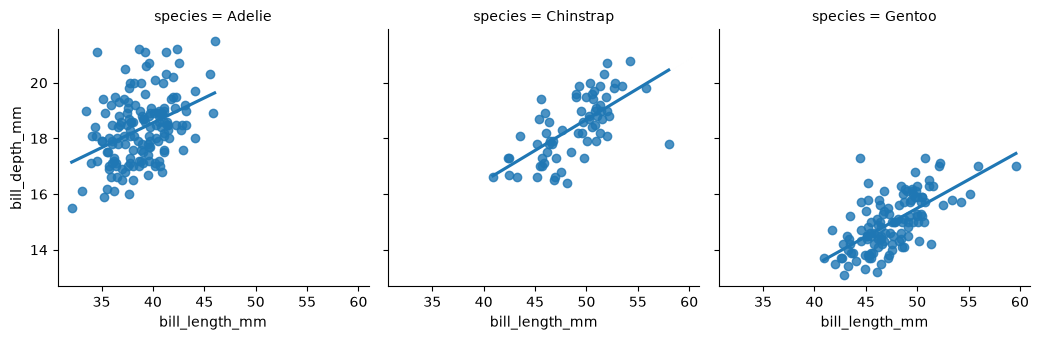

In [20]:
sns.lmplot(data=df, x="bill_length_mm", y="bill_depth_mm", col="species",
           height=3.5, ci=None)
plt.show()

### The catch: `ax=` does not work on figure-level functions

Because a figure-level function creates its own Figure, it cannot draw into a panel that
already exists. Passing `ax=` is an error:

```python
fig, axes = plt.subplots(1, 2)
sns.displot(data=df, x="body_mass_g", ax=axes[0])   # TypeError
```

::: {.callout-important}
## The mistake everyone makes once

This is the most common seaborn error there is, and the fix is always to ask whether you
need the figure-level function at all:

- **Putting a seaborn plot into a grid you built?** Use the **axes-level** function with
  `ax=`: `histplot` not `displot`, `scatterplot` not `relplot`, `boxplot` not `catplot`,
  `regplot` not `lmplot`.
- **Want seaborn to build the grid for you, by splitting on a column?** Use the
  **figure-level** function with `col=` / `row=`, and let it own the figure.

A quick way to tell which you are holding: figure-level functions take `height` and
`aspect` (they size their own figure) and a `kind` argument; axes-level functions take
`ax` and no `kind`. Figure-level names also end in `-plot` after a short prefix —
`displot`, `relplot`, `catplot`, `lmplot` — and are easy to misread as the axes-level
names they wrap. `displot` and `histplot` are different functions; so are `relplot` and
`scatterplot`.
:::

### Working with what a figure-level function returns

A figure-level call returns a `FacetGrid` object rather than Axes, and you adjust the
result through it:

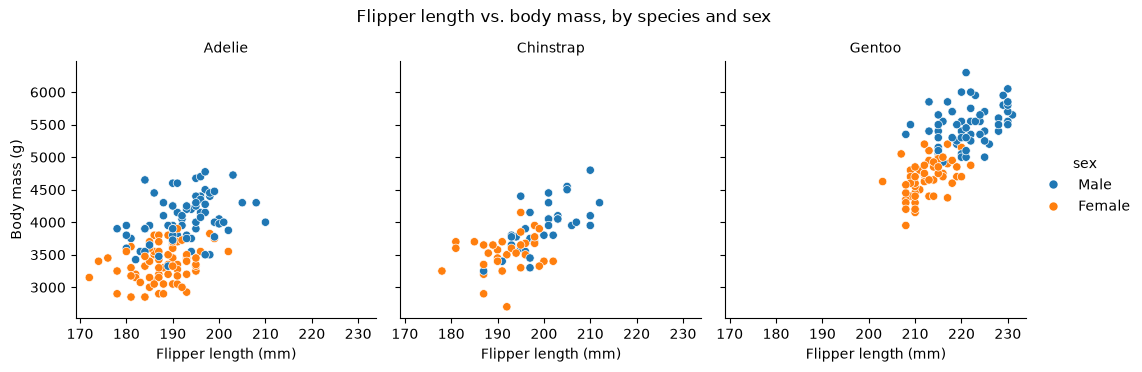

In [21]:
g = sns.relplot(data=df, x="flipper_length_mm", y="body_mass_g",
                col="species", hue="sex", height=3.5)

g.set_axis_labels("Flipper length (mm)", "Body mass (g)")
g.set_titles("{col_name}")
g.figure.suptitle("Flipper length vs. body mass, by species and sex", y=1.05)
plt.show()

| On a `FacetGrid` `g` | What it does |
|---|---|
| `g.set_axis_labels(x, y)` | Label the x and y axes across all panels |
| `g.set_titles("{col_name}")` | Retitle panels; `{col_name}` is the group's value |
| `g.figure` | The underlying Figure — for `suptitle`, `savefig` |
| `g.axes` | The array of underlying Axes, if you need one directly |
| `g.axes.flat[0]` | The first panel, e.g. to add an annotation |
| `g.savefig("name.png")` | Save the figure |
| `col_wrap=3` | Wrap a long row of facets onto multiple rows |

`col_wrap` matters when the faceting column has many values. With `col=` alone, seaborn
puts every panel in a single row, which gets uncomfortably wide past four or five groups;
`col_wrap=3` breaks that row after three panels and continues below. Our penguin columns
only have three values each, so there is nothing to wrap here — but remember it the first
time you facet on something like a 12-month column.

Faceting on two columns at once, with `col=` and `row=`, gives a grid of every
combination:

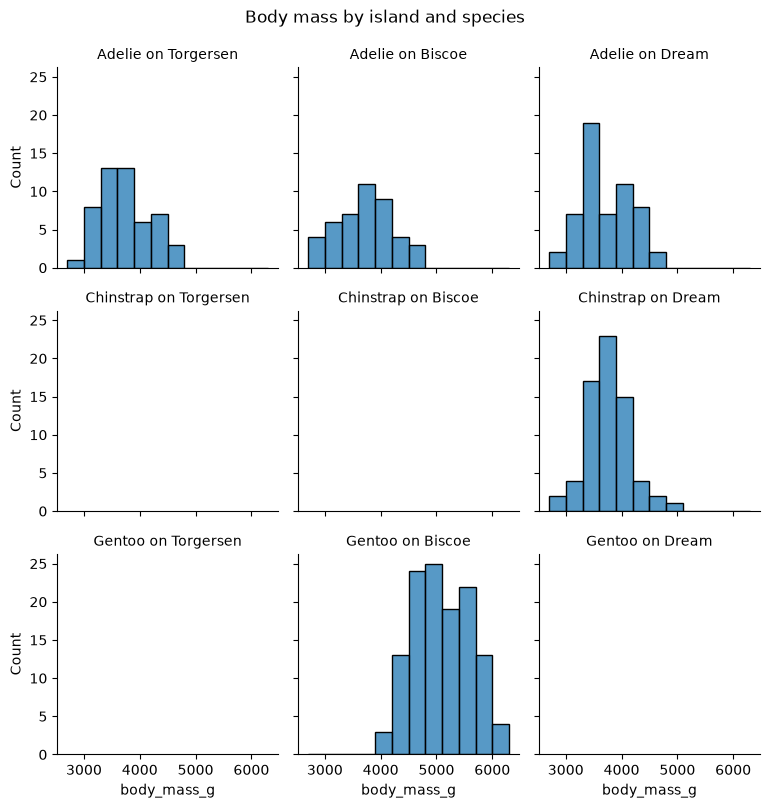

In [22]:
g = sns.displot(data=df, x="body_mass_g", col="island", row="species",
                bins=12, height=2.6)
g.set_titles("{row_name} on {col_name}")
g.figure.suptitle("Body mass by island and species", y=1.03)
plt.show()

Two things to notice.

First, `set_titles` is doing necessary work. Seaborn's default title for a two-way facet
is the full `species = Chinstrap | island = Biscoe`, and nine of those across a grid this
size run into each other and become unreadable. `"{row_name} on {col_name}"` substitutes
just the group values, giving "Chinstrap on Biscoe".

Second, **four panels are empty**, and that is the most informative thing in the figure.
Faceting creates a slot for every combination of the two columns, whether or not any rows
fall into it, so the blanks show you exactly which combinations do not occur: no Gentoos
except on Biscoe, no Chinstraps except on Dream. That is the island/species structure we
found with a heatmap in the last chapter, arrived at from a different direction. An empty
facet is not a bug in your code — it is data.

## Sharing a legend across panels

When every panel uses the same colors, a legend in each one is repeated clutter. The fix
is to take the legend entries from one panel, remove the per-panel legends, and attach a
single legend to the figure.

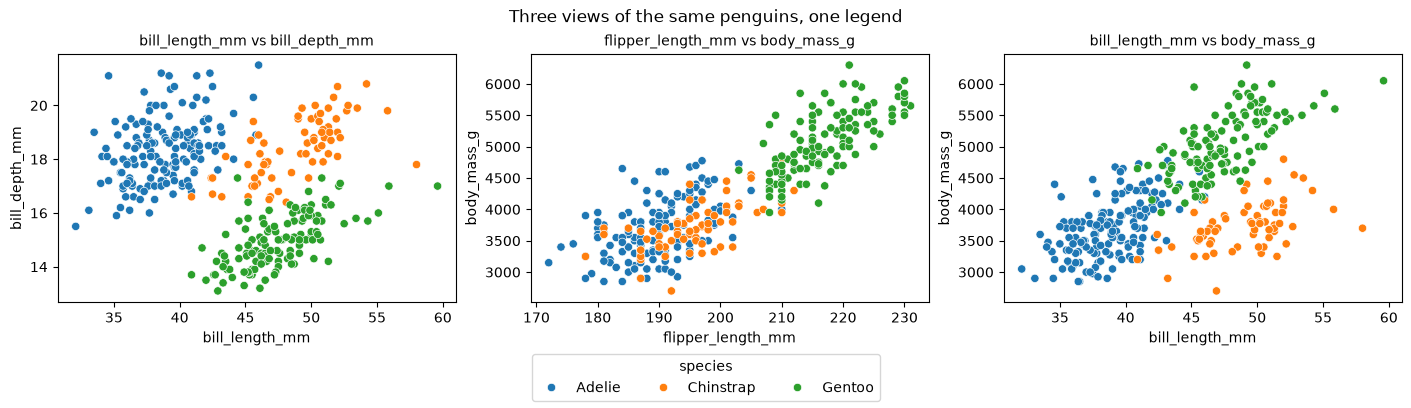

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), layout="constrained")

numeric_pairs = [("bill_length_mm", "bill_depth_mm"),
                 ("flipper_length_mm", "body_mass_g"),
                 ("bill_length_mm", "body_mass_g")]

for i, (ax, (xcol, ycol)) in enumerate(zip(axes, numeric_pairs)):
    # Let ONLY the first panel build a legend — we harvest it, then delete it.
    sns.scatterplot(data=df, x=xcol, y=ycol, hue="species", ax=ax,
                    legend=(i == 0))
    ax.set_title(f"{xcol} vs {ycol}", fontsize=10)

handles, labels = axes[0].get_legend_handles_labels()
axes[0].get_legend().remove()

fig.legend(handles, labels, title="species",
           loc="outside lower center", ncols=3)

fig.suptitle("Three views of the same penguins, one legend")
plt.show()

The mechanics are worth stepping through, because there is a trap in the obvious version:

1. `legend=(i == 0)` passes `True` for the first panel and `False` for the other two, so
   exactly one legend gets built.
2. `get_legend_handles_labels()` reads that panel's legend entries — the colored markers
   (`handles`) and the species names (`labels`).
3. `axes[0].get_legend().remove()` then deletes the per-panel legend, now that we have
   its contents.
4. `fig.legend(handles, labels, ...)` attaches them once to the figure.

The trap is step 1. It is tempting to pass `legend=False` to *every* panel and then ask
for the handles, but a panel that never drew a legend has no labelled artists, so
`get_legend_handles_labels()` returns two empty lists and `fig.legend` renders a legend
box containing nothing but its title. **You have to let one panel build a legend in order
to steal it.**

The `loc="outside lower center"` position requires `layout="constrained"`, which is one
of the places constrained layout beats `tight_layout()`. `ncols=3` lays the three entries
out in a row rather than a column, which suits a legend under a wide figure.

If a seaborn function has already drawn a legend you want gone, remove it directly:

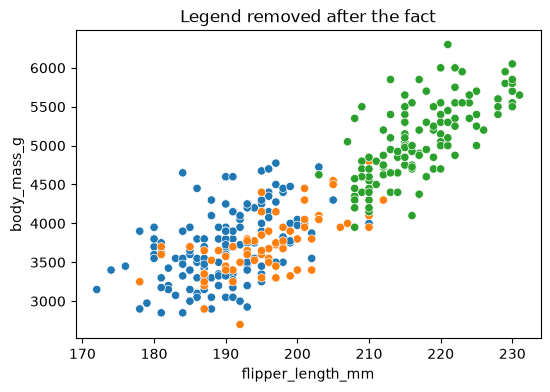

In [24]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(data=df, x="flipper_length_mm", y="body_mass_g",
                hue="species", ax=ax)
ax.get_legend().remove()
ax.set_title("Legend removed after the fact")
plt.show()

## Two y-axes on one panel

Occasionally you want two variables with completely different units on the same panel.
`ax.twinx()` creates a second Axes sharing the same x-axis but with its own y-axis on the
right.

The two lists of means below are typed in as literal numbers rather than computed,
because computing a mean per species needs `.groupby()`, which comes in a later chapter.
They are the real values for this dataset — the same body-mass means you saw behind the
bar chart in the last chapter.

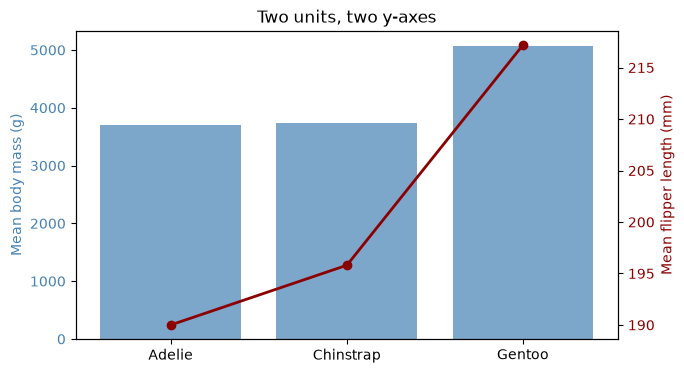

In [25]:
fig, ax_left = plt.subplots(figsize=(7, 4))

species_list = ["Adelie", "Chinstrap", "Gentoo"]
mass_means = [3700.7, 3733.1, 5076.0]        # grams
flipper_means = [190.0, 195.8, 217.2]        # millimetres

ax_left.bar(species_list, mass_means, color="steelblue", alpha=0.7)
ax_left.set_ylabel("Mean body mass (g)", color="steelblue")
ax_left.tick_params(axis="y", labelcolor="steelblue")

ax_right = ax_left.twinx()
ax_right.plot(species_list, flipper_means, color="darkred", marker="o", linewidth=2)
ax_right.set_ylabel("Mean flipper length (mm)", color="darkred")
ax_right.tick_params(axis="y", labelcolor="darkred")

ax_left.set_title("Two units, two y-axes")
plt.show()

Colour-coding each axis label to match its data is not decoration here — with two scales
it is the only thing telling the reader which line belongs to which axis.

::: {.callout-important}
## Use two y-axes sparingly

A twin-axis plot is easy to mislead with, because **you chose the two scales**. Sliding
one axis range up or down changes where the lines cross and which appears to lead the
other, and the "relationship" a reader sees can be manufactured entirely by that choice.

Prefer two panels with `sharex=True`. The comparison stays honest, and the reader is
never asked to track which line goes with which axis. Reach for `twinx` only when the two
series genuinely belong in one frame — and say in the caption that the scales differ.
:::

## Use an Inset to Show Detail

Two y-axes squeeze a second *scale* into one panel. An inset does something gentler: it
puts a second *view of the same data* inside the panel. It is the tool for a plot that is
right overall but crowded in one region — the main panel keeps the full range while a
small panel inside it magnifies the part where the points pile up.

`ax.inset_axes([left, bottom, width, height])` creates that small Axes as a child of the
panel, positioned in fractions of the parent. `[0.58, 0.06, 0.40, 0.29]` starts 58% of
the way across and 6% up, and takes 40% of the width and 29% of the height. Because the
numbers are relative to the parent, the inset stays put when the surrounding layout
changes. (`fig.add_axes(...)` takes figure coordinates instead, which is what you want
when a small Axes should sit somewhere in the figure independently of any panel.)

`ax.indicate_inset_zoom()` then draws the rectangle marking the magnified region and the
lines connecting it to the inset. Without it, the reader has to work out the relationship
from the axis numbers alone.

An inset also needs somewhere to sit where it covers nothing. This scatter has no
penguins with long flippers and low body mass, so its bottom-right corner is free, and
widening the limits a little past the data with `ax.set(xlim=..., ylim=...)` makes that
corner roomier without moving a single point.

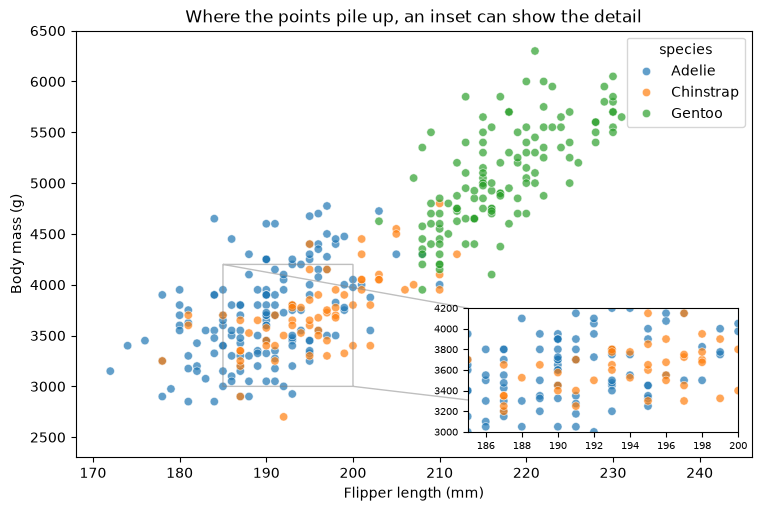

In [26]:
fig, ax = plt.subplots(figsize=(7.5, 5), layout="constrained")

sns.scatterplot(data=df, x="flipper_length_mm", y="body_mass_g", hue="species",
                alpha=0.7, ax=ax)
ax.set_xlabel("Flipper length (mm)")
ax.set_ylabel("Body mass (g)")
ax.set_title("Where the points pile up, an inset can show the detail")

# Widen the limits past the data, clearing a corner for the inset.
ax.set(xlim=(168, 246), ylim=(2300, 6500))

# A child Axes, placed in fractions of the parent panel.
zoom = ax.inset_axes([0.58, 0.06, 0.40, 0.29])
sns.scatterplot(data=df, x="flipper_length_mm", y="body_mass_g", hue="species",
                alpha=0.7, legend=False, ax=zoom)
zoom.set(xlim=(185, 200), ylim=(3000, 4200), xlabel="", ylabel="")
zoom.tick_params(labelsize=7)

ax.indicate_inset_zoom(zoom, edgecolor="gray")
plt.show()


Two details of craft. **Put the inset where the data is not**: the magnified view sits in
the empty corner, so it hides nothing — and that includes the inset's own tick labels,
which are drawn outside its frame and will cover points if you place it too tightly.
Widening the limits is the cheap way to clear that space. If no corner can be freed, the
region deserves its own panel instead.

**Keep the inset's ticks.** The temptation is to strip them for tidiness, but an inset
has a different scale from its parent and those numbers are the only thing saying so.
Here `legend=False` drops the duplicate legend and the axis *labels* are dropped because
the parent already names both variables — the tick numbers stay.

An inset does not have to be a magnified copy. It is an ordinary Axes, so it can hold any
plot at all, and a common use is a small summary tucked into a corner of the main panel:
the distribution of one variable, or a compact comparison across groups.

The figure below places two of them with `fig.add_axes([left, bottom, width, height])`,
which takes the same four numbers as **figure** coordinates rather than fractions of a
panel. That is the right tool when a small Axes belongs to the figure as a whole rather
than to one panel, and the cost is exactly that: you are positioning against the whole
canvas, so a change in the surrounding layout can leave the inset stranded. `facecolor`
sets each one apart from the scatter behind it, and
`sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1))` pushes the legend outside
the panel, because the insets wanted the corner it was sitting in. The limits are widened
here too, for the same reason as before — the lower-right inset needs a clear corner, and
its species labels sit outside its frame.

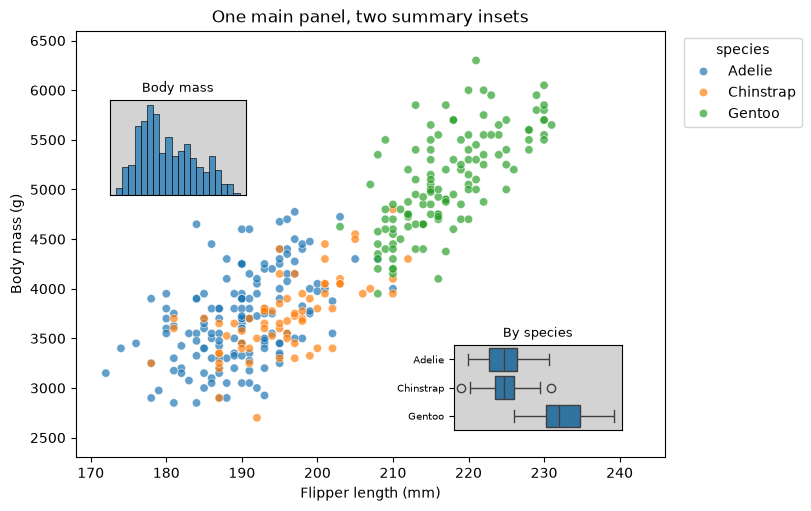

In [27]:
fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")

sns.scatterplot(data=df, x="flipper_length_mm", y="body_mass_g", hue="species",
                alpha=0.7, ax=ax)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1))
ax.set_xlabel("Flipper length (mm)")
ax.set_ylabel("Body mass (g)")
ax.set_title("One main panel, two summary insets")
ax.set(xlim=(168, 246), ylim=(2300, 6600))

# Figure coordinates: positioned against the whole canvas, not the panel.
hist_ax = fig.add_axes([0.13, 0.62, 0.17, 0.19], facecolor="lightgray")
sns.histplot(data=df, x="body_mass_g", bins=20, ax=hist_ax)
hist_ax.set(title="Body mass", xlabel="", ylabel="", xticks=[], yticks=[])
hist_ax.title.set_size(9)

box_ax = fig.add_axes([0.56, 0.15, 0.21, 0.17], facecolor="lightgray")
sns.boxplot(data=df, x="body_mass_g", y="species", ax=box_ax)
box_ax.set(title="By species", xlabel="", ylabel="", xticks=[])
box_ax.title.set_size(9)
box_ax.tick_params(labelsize=7)

plt.show()


Both insets earn their corners: the upper left of this scatter holds no penguins, and
neither does the lower right.

Their ticks are gone, which is the opposite of the advice one figure ago — deliberately.
A **zoom** inset has to show its scale, because the reader needs to know how far in it
went. A **summary** inset like these two makes a claim about shape and order rather than
about particular values, so stripping the ticks removes clutter without removing the
point. Decide which kind you are drawing before you decide about ticks.

## Formatting Tick Labels

The last few sections added things to a panel. This one changes how the panel's own
numbers read. Matplotlib writes tick labels straight from the data, which gives you
`6000` where a reader expects `6,000`, and `0.44` where they expect `44%`. The fix lives
on the axis objects `ax.xaxis` and `ax.yaxis` — another place where having the object in
hand is what makes the adjustment possible.

`set_major_formatter` accepts a format string in which `{x}` stands for the tick value.
`'{x:,.0f}'` is a thousands separator with no decimals; `'{x:.0%}'` turns a proportion
into a percentage.

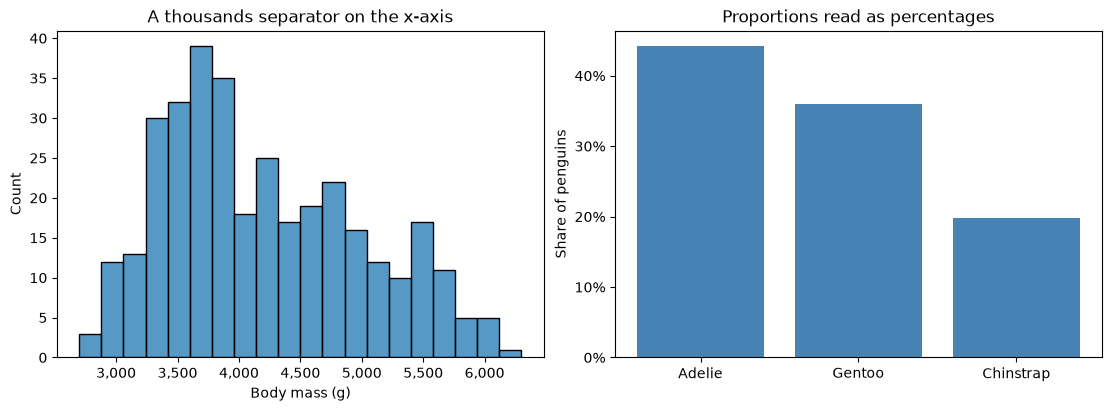

In [28]:
fig, (ax_mass, ax_share) = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")

sns.histplot(data=df, x="body_mass_g", bins=20, ax=ax_mass)
ax_mass.xaxis.set_major_formatter('{x:,.0f}')
ax_mass.set(xlabel="Body mass (g)", title="A thousands separator on the x-axis")

shares = df["species"].value_counts(normalize=True)
ax_share.bar(shares.index, shares.values, color="steelblue")
ax_share.yaxis.set_major_formatter('{x:.0%}')
ax_share.set(ylabel="Share of penguins", title="Proportions read as percentages")

plt.show()

The right-hand panel holds proportions — `value_counts(normalize=True)`, from Pandas
Fundamentals — so the values behind the bars are 0.442, 0.360, and 0.198. The formatter
is what makes them read as the percentages a caption would quote, and the data itself is
untouched: format for the reader rather than by rewriting your numbers.

Two adjustments you will reach for on the same figures: `ax.tick_params(axis="x",
rotation=45)` when category names overlap, and `ax.set_xticks([...])` when you want to
choose the tick positions yourself instead of accepting matplotlib's.

### A detour for larger numbers

Penguin masses run in the low thousands, so the separator above is a small improvement.
It becomes a real one once counts reach five figures. For one figure only, this section
borrows another dataset that ships with seaborn — 53,940 diamonds, nothing to
download — to show what the formatter is actually for.

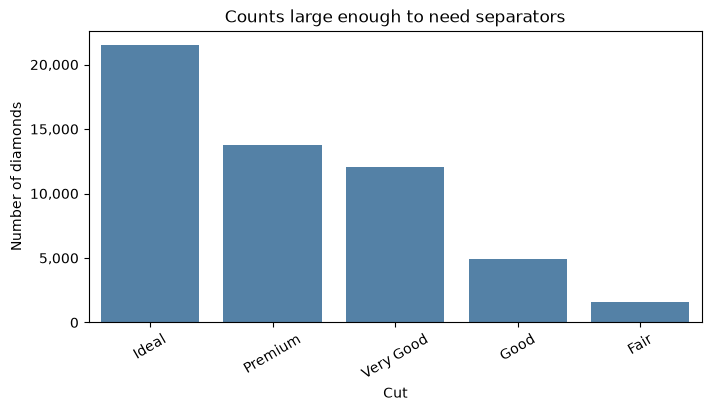

In [29]:
diamonds = sns.load_dataset("diamonds")

fig, ax = plt.subplots(figsize=(7, 4), layout="constrained")

sns.countplot(data=diamonds, x="cut", order=diamonds["cut"].value_counts().index,
              color="steelblue", ax=ax)
ax.yaxis.set_major_formatter('{x:,.0f}')
ax.tick_params(axis="x", rotation=30)
ax.set(xlabel="Cut", ylabel="Number of diamonds",
       title="Counts large enough to need separators")

plt.show()

`21551` against `21,551`: at this size the separator is the difference between reading a
number and counting its digits. The same figure shows the rotation argument doing its job
on category names long enough to collide.

The rest of the chapter returns to the penguins.

## Saving a multi-panel figure

With a figure in a variable, save it with `fig.savefig`:

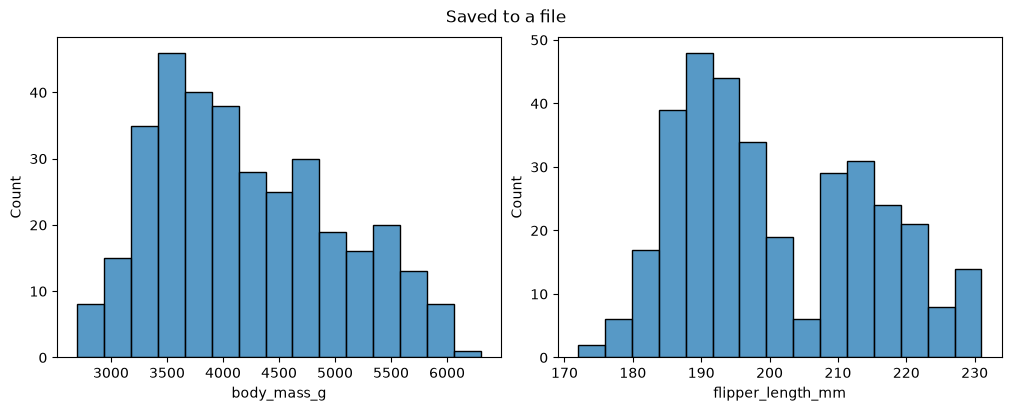

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
sns.histplot(data=df, x="body_mass_g", bins=15, ax=axes[0])
sns.histplot(data=df, x="flipper_length_mm", bins=15, ax=axes[1])
fig.suptitle("Saved to a file")

fig.savefig("penguin_panels.png", dpi=300, bbox_inches="tight")
plt.show()

Three points, two of which bit us in the last chapter:

- **`fig.savefig`, not `plt.savefig`.** With several figures in flight, `plt.savefig`
  saves whichever is current — name the one you mean.
- **Save before `plt.show()`.** `plt.show()` closes out the figure, so saving afterwards
  writes a blank image. In the explicit interface this is less dangerous, since `fig`
  still refers to the figure, but keep the habit.
- **`bbox_inches="tight"`** crops surrounding whitespace and, importantly, stops a
  `suptitle` or an outside legend from being cut off. `dpi=300` is a reasonable
  resolution for print.

For a figure-level seaborn plot, save through the `FacetGrid`: `g.savefig("name.png")`, or
equivalently `g.figure.savefig(...)`.

In [31]:
#| echo: false
import os
if os.path.exists("penguin_panels.png"):
    os.remove("penguin_panels.png")

## Designing a multi-panel figure

The mechanics are the easy part. Four habits separate a readable grid from a confusing
one:

**Share the axes when the panels share a variable.** Unshared axes make panels look
comparable while quietly rescaling each one. Use `sharex` / `sharey`, and if you cannot,
say so.

**Let one panel carry one idea.** A grid works because each panel is simple and the
reader learns to read it once. If a panel needs its own explanation, it probably wants to
be its own figure.

**Keep the panels in a meaningful order.** Left to right, top to bottom is how people
read. Order panels by size, time, or importance rather than alphabetically by accident —
`order=` and `col_order=` exist for this.

**Give the figure enough room.** A 2×3 grid at the default figure size produces six
cramped, unreadable panels. Scale `figsize` with the grid, and use
`layout="constrained"`.

And the question that comes before all of them: should this be one figure at all? Panels
earn their place when the reader will *compare* them. Six unrelated plots in a grid are
harder to read than six plots one after another, because the grid implies a relationship
that isn't there.

## Summary Cheat Sheet {#summary-cheat-sheet}

**The anatomy.** A **Figure** is the canvas; an **Axes** is one panel; an **Axis** is one
number line; **Artists** are the things drawn. "Axes" means panel.

**The two interfaces.**

```python
# Implicit (pyplot): fine for a single quick plot
plt.hist(data)
plt.xlabel("x")

# Explicit (object-oriented): use this for everything else
fig, ax = plt.subplots()
ax.hist(data)
ax.set_xlabel("x")
```

Plotting commands keep their names, labelling commands gain `set_`, panel properties live
on `ax`, and figure properties live on `fig`.

**Building grids.**

| Goal | Tool |
|---|---|
| One panel | `fig, ax = plt.subplots()` |
| A regular grid | `fig, axes = plt.subplots(nrows, ncols)` |
| Loop over panels | `for ax, thing in zip(axes.flat, things):` |
| Uneven layout | `plt.subplot_mosaic("AAB\nAAC")` |
| Fine control of an uneven layout | `fig.add_gridspec` + `fig.add_subplot(gs[...])` |
| Comparable panels | `sharex=True`, `sharey=True` |
| Spacing that works | `layout="constrained"` |
| A magnified inset | `ax.inset_axes([left, bottom, w, h])` + `ax.indicate_inset_zoom(inset)` |
| A summary inset, in figure coordinates | `fig.add_axes([left, bottom, w, h], facecolor=...)` |
| Thousands separator / percentages | `ax.yaxis.set_major_formatter('{x:,.0f}')` / `'{x:.0%}'` |
| Rotate tick labels | `ax.tick_params(axis="x", rotation=45)` |
| Move a legend out of the panel | `sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1))` |
| Figure-wide text | `fig.suptitle`, `fig.supxlabel`, `fig.supylabel` |
| Saving | `fig.savefig(..., dpi=300, bbox_inches="tight")` |

**Seaborn's two kinds of function.**

|  | Axes-level | Figure-level |
|---|---|---|
| Examples | `histplot`, `scatterplot`, `boxplot`, `regplot` | `displot`, `relplot`, `catplot`, `lmplot` |
| Draws into | A panel you give it, via `ax=` | Its own new figure |
| Builds panels for you | No | Yes, via `col=` / `row=` |
| Distinctive arguments | `ax=` | `kind=`, `height=`, `aspect=`, `col_wrap=` |
| Returns | An `Axes` | A `FacetGrid` |
| Use it when | You are assembling a figure yourself | You want faceting by a column |

The rule to remember: **`ax=` for a panel you built, `col=` for panels seaborn builds.**

## Practice Activity: Build and Defend a Multi-Panel Figure {#practice-activity-build-and-defend-a-multi-panel-figure}

**Goal:** Assemble figures out of panels, choose between building them yourself and letting seaborn facet them, and say what each choice cost.

**File:** `activity09.ipynb` from the [practice kit](https://lizhen0909.github.io/stat303-1-sec20-coursebook/downloads/data-visualization-2-practice.zip).

**Submit:** `activity09.html` through the final upload question in the Data Visualization II Canvas quiz.

**This section contains the complete activity instructions.** The starter loads the data and supplies spaces to record your work. Open `activity09.ipynb` from the folder prepared in [Set Up Your Chapter Files](#set-up-your-chapter-files), using the same project environment. The worked examples above are preparation, not additional submission requirements.

You will use the same Palmer penguins dataset, loaded the same way, so the activity needs no data file of its own.

### A. The Two Interfaces, and a Title That Goes Astray {.unnumbered}

- Replace `Your Name` in the opening Raw cell's `author` field. Run the setup cell; it must report the shape `(344, 7)`.
- Draw a histogram of `bill_length_mm` twice, once with the pyplot interface and once with the object-oriented interface, giving each an x-label and a title. Say in one sentence what `fig` and `ax` refer to in the second version.
- Build a 1×2 figure, draw into both panels, and then call `plt.title("Left panel")`. Report where the title actually appeared and explain why. Fix it so the title lands on the left panel.

### B. A Grid Whose Panels Are Comparable {.unnumbered}

- Create `fig, axes = plt.subplots(2, 2)`. Before running anything, write down the index of the bottom-left panel and the value of `axes.shape`; then confirm both by setting that panel's title.
- Build a 1×3 figure comparing `body_mass_g` across the three species: a box plot, a violin plot, and a bar chart of means, one per panel.
- Use `sharey=True` and explain in a sentence why sharing the y-axis matters for this comparison. Give the figure a size that leaves the panels readable.

### C. Looping Over Panels, and One Figure-Wide Label {.unnumbered}

- Using `zip` and `axes.flat`, draw a 2×2 grid of scatter plots of `body_mass_g` against each of the four numeric columns.
- One panel plots body mass against itself. Say what that panel shows, then replace it with something a reader would learn from.
- Give the figure a single figure-wide title instead of four panel titles, and label the shared axes once. Save it as a 300-dpi PNG and confirm nothing is cut off.

### D. Axes-Level or Figure-Level {.unnumbered}

- Draw `sns.displot(data=df, x="body_mass_g", col="species")`, then rebuild the same figure with `plt.subplots()` and `sns.histplot(..., ax=...)`. Say which version was shorter and what you had to do by hand.
- Explain why the same call fails when you pass `ax=` to `sns.catplot()` but works with `sns.boxplot()`, and name the argument that tells you at a glance which kind of function you are holding.
- Use `sns.lmplot` to fit one regression line per species for `bill_depth_mm` against `bill_length_mm`, and say what that figure shows that a single pooled line hid in the previous chapter.

### Render and Submit {.unnumbered}

Restart the kernel, run all cells in order, resolve unexpected errors, and save. Include your figures, outputs, and explanations for A–D, and a short Markdown completion note. From `stat303-data-visualization-2` in the terminal, run:

```text
quarto render activity09.ipynb --to html
```

Follow the [Quarto refresher](https://lizhen0909.github.io/stat303-1-sec20-coursebook/vscode_setup.html#render-and-submit-with-quarto): inspect the HTML and a copy opened outside the project folder, and confirm that every figure appears and your name is on the report. Upload only `activity09.html` to the Data Visualization II Canvas quiz; keep your notebook locally.

**HTML grading (16 points):** both interfaces drawn, `fig`/`ax` explained, and the misplaced title diagnosed and fixed (4); panel indexing, `axes.shape`, the three-panel comparison, and the `sharey` justification (4); the looped grid, the self-comparison panel replaced, figure-wide labelling, and a clean saved file (4); the faceted figure rebuilt by hand, the `ax=` explanation, and the per-species regression lines (3); name, readable report, and completion note (1).

## Extended Practice {#extended-practice}

These longer exercises are additional practice, not requirements for the Canvas quiz.
Work in a separate notebook beside your activity and load the data the way the chapter
does. Include your code, figures, and explanations.

### Mosaic against GridSpec

Reproduce this chapter's `subplot_mosaic` figure using `GridSpec` instead. Then say which
version you would rather maintain, and what `GridSpec` gives you that the mosaic string
cannot.

### Empty Panels, and What They Tell You

Facet body mass with `sns.displot` twice: once with `col="island", row="species"`, and
once with `col="island", row="sex"`. The first has empty panels and the second does not.
Explain what that difference tells you about the two pairs of variables.

### One Legend for the Whole Figure

Build a 1×3 figure in which each panel is coloured by species, then remove the three
panel legends and give the figure a single shared legend. Explain what goes wrong if you
simply call `ax.legend()` on the last panel instead.

### Two Y-Axes, and Whether to Use Them

Draw one panel with two y-axes using `ax.twinx()`, then draw the same information as two
stacked panels sharing an x-axis. Argue for one of the two versions as the one you would
publish, and name the specific way the twin-axis version can mislead a reader.

## Before You Move On {#before-you-move-on}

The habit to carry forward is naming the thing you draw into. A single quick plot can go
through `plt.*` and land wherever pyplot puts it, but as soon as a figure has more than
one panel, every command needs an address: `ax` for a panel, `fig` for the whole canvas.
Axes-level seaborn functions take that address through `ax=`; figure-level ones refuse it,
because they build the figure themselves.

The other habit is asking whether the panels belong together. A grid tells the reader
that the panels are worth comparing, so it should be true: shared axes when they share a
variable, a meaningful order, one idea per panel, and enough room that none of it is
cramped.

For any multi-panel figure you make or read, you should be able to answer five questions:

1. What is one panel, and what changes from panel to panel?
2. Are the axes shared, and if not, could a reader mistake the panels for comparable?
3. Which commands addressed a panel, and which addressed the whole figure?
4. Did seaborn build these panels, or did you — and does the function you called accept `ax=`?
5. Would these plots be easier to read one after another instead of side by side?

Continue to [Data Cleaning](https://lizhen0909.github.io/stat303-1-sec20-coursebook/Data_cleaning.html), where the messy realities you have been
plotting around — missing values, wrong types, duplicated records — become the subject
rather than a footnote.

References: [matplotlib quick start](https://matplotlib.org/stable/users/explain/quick_start.html),
[figure anatomy](https://matplotlib.org/stable/gallery/showcase/anatomy.html),
[`plt.subplots`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html),
[`subplot_mosaic`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplot_mosaic.html),
[constrained layout](https://matplotlib.org/stable/users/explain/axes/constrainedlayout_guide.html),
[seaborn figure-level versus axes-level functions](https://seaborn.pydata.org/tutorial/function_overview.html),
and [`FacetGrid`](https://seaborn.pydata.org/generated/seaborn.FacetGrid.html).